In [1]:
%load_ext autoreload
%autoreload 2
# import jtplot submodule from jupyterthemes
# from jupyterthemes import jtplot
# jtplot.style()
%load_ext tensorboard

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("..") # Add s higher directory to python modules path.
from environment.environment import *
from engine.agent.base_agent import *
from engine.policy.base_policy import *
np.set_printoptions(suppress=True)

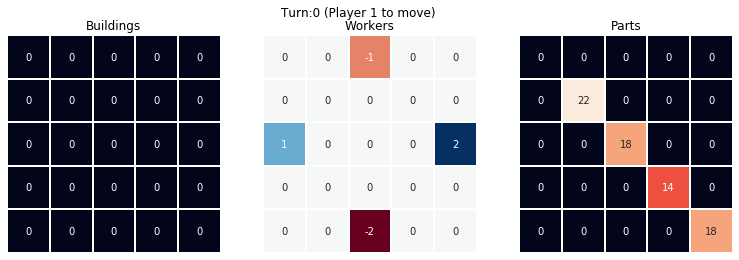

In [7]:
env = Santorini()
env.print_board(mode=1)

# Environment Testing

In [8]:
#initiate env
env = Santorini()
#initiate policy
policy = RandomPolicy()
#initiate players
player1 = OneStepAgent(policy, -1)
player2 = OneStepAgent(policy,  1)

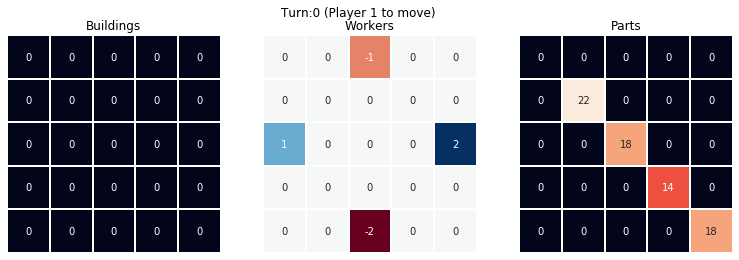

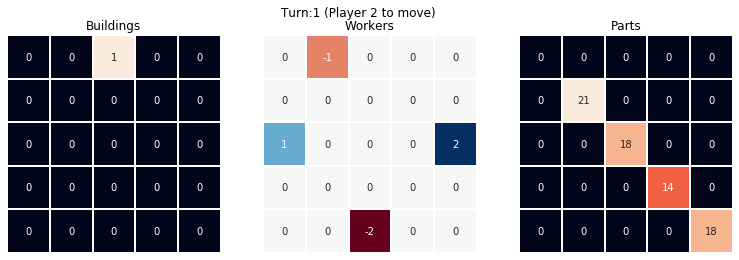

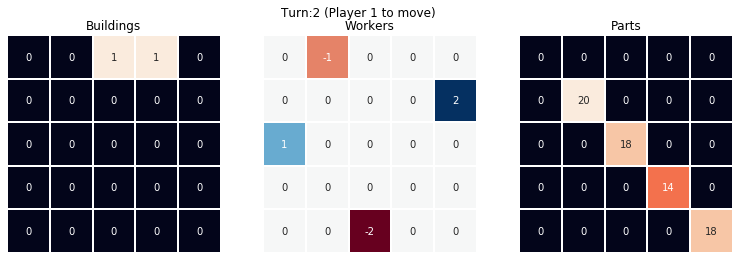

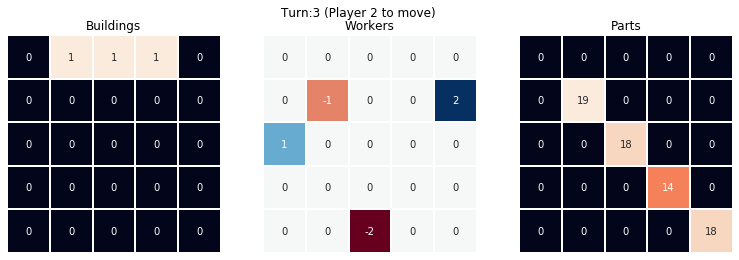

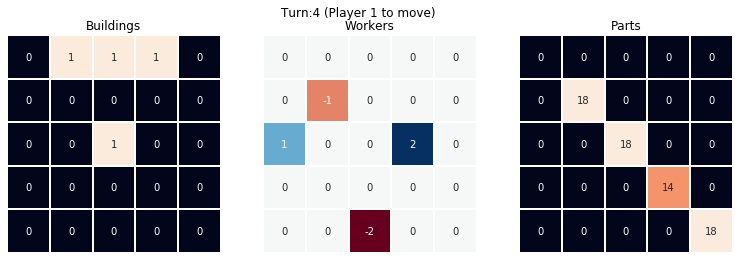

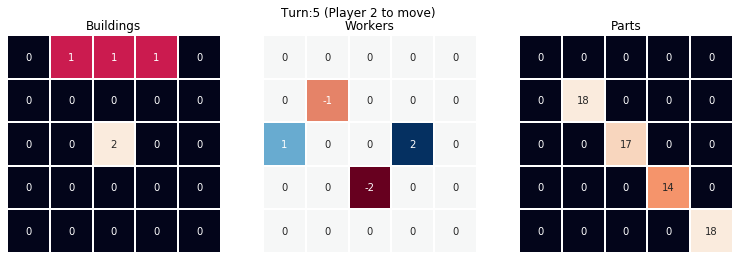

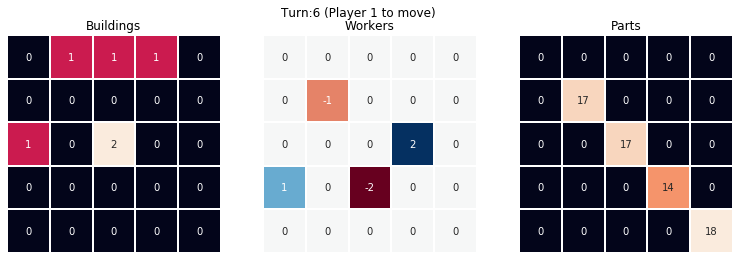

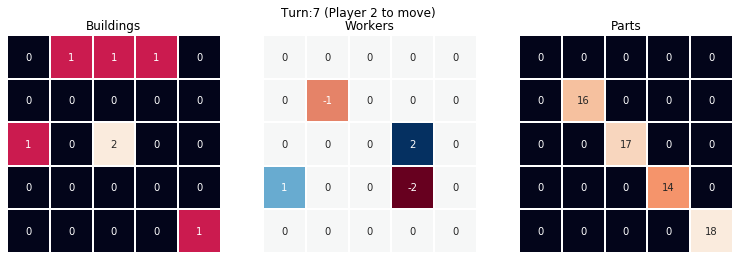

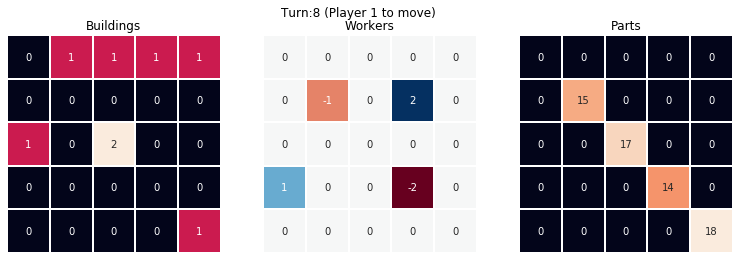

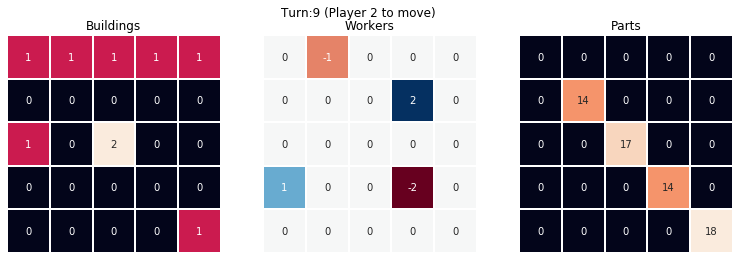

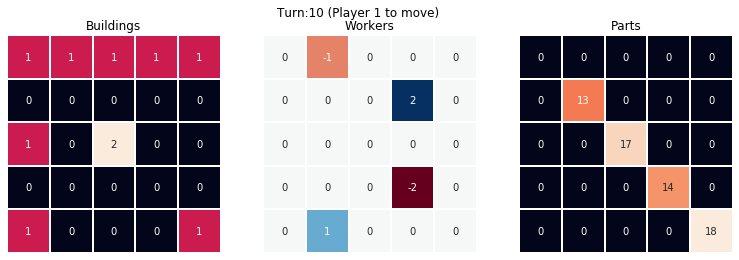

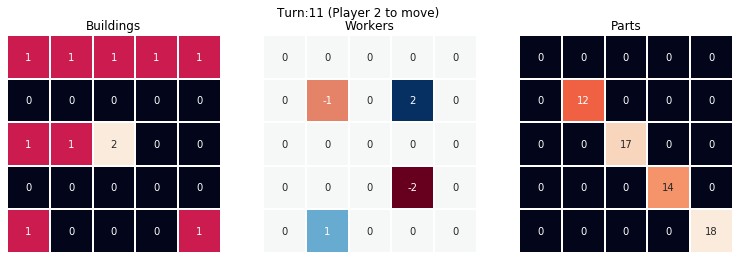

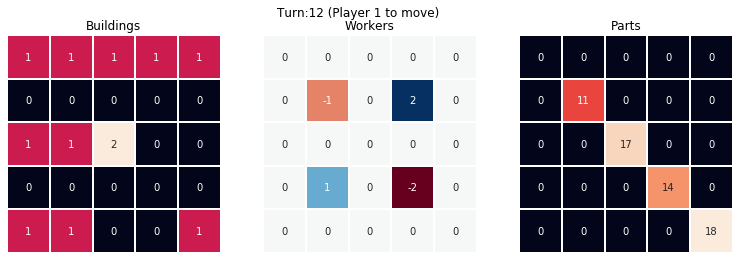

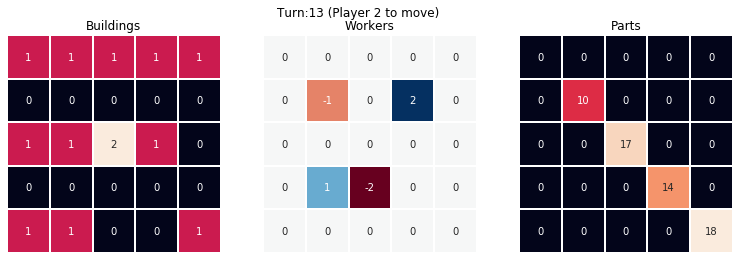

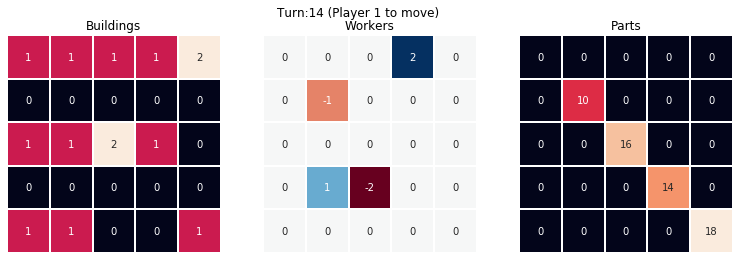

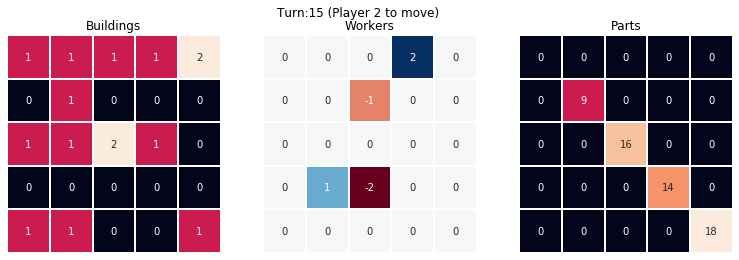

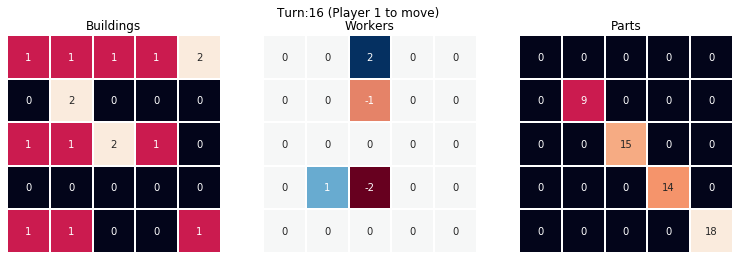

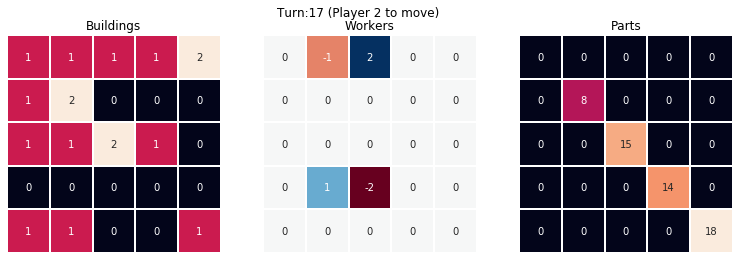

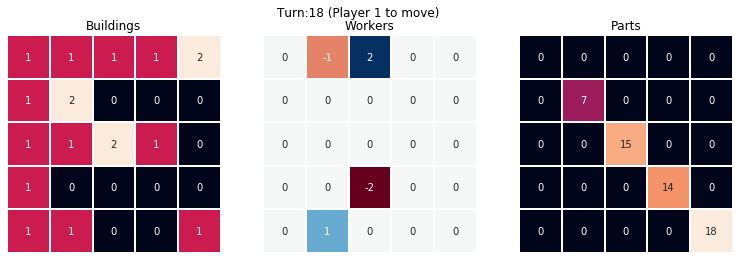

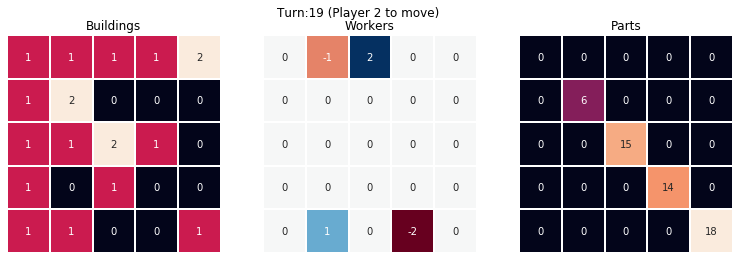

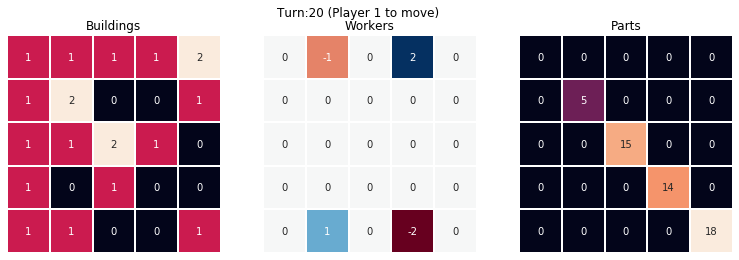

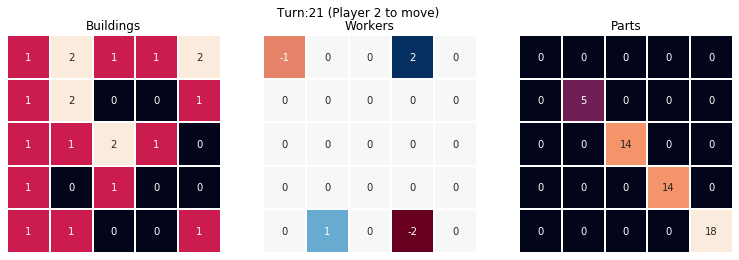

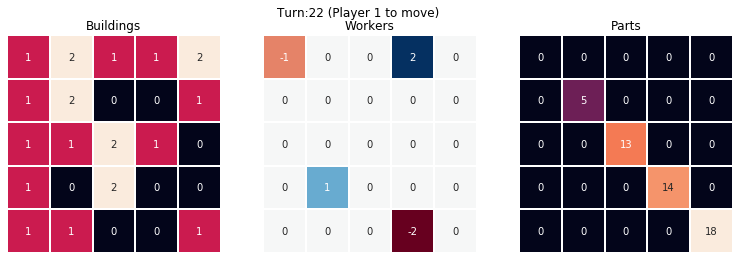

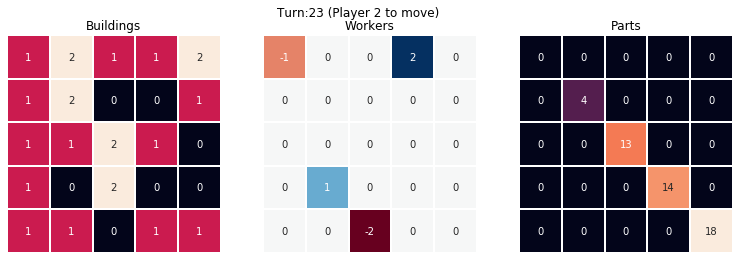

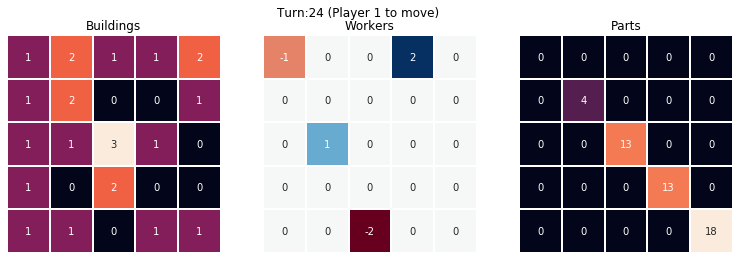

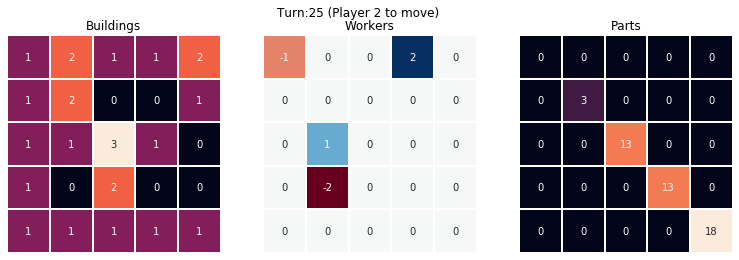

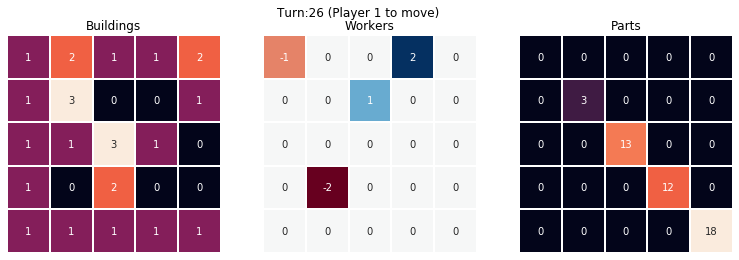

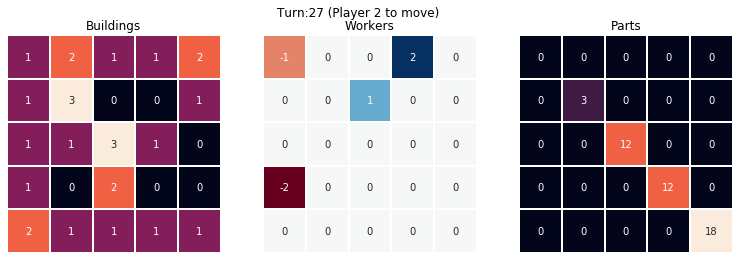

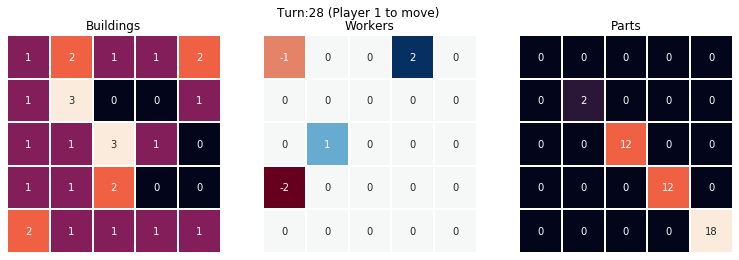

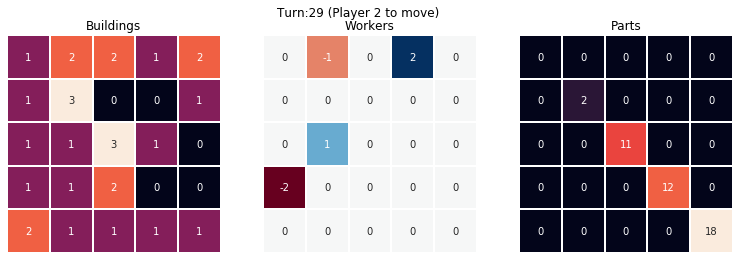

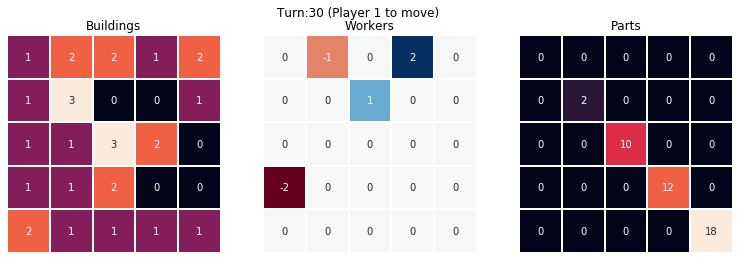

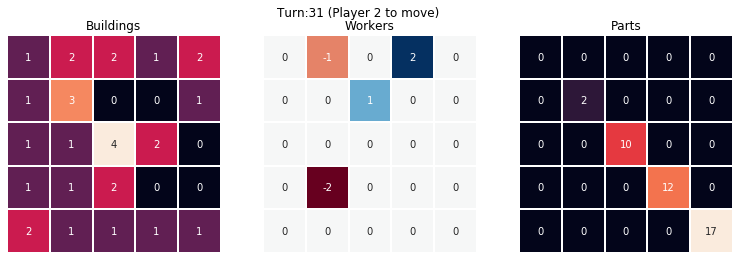

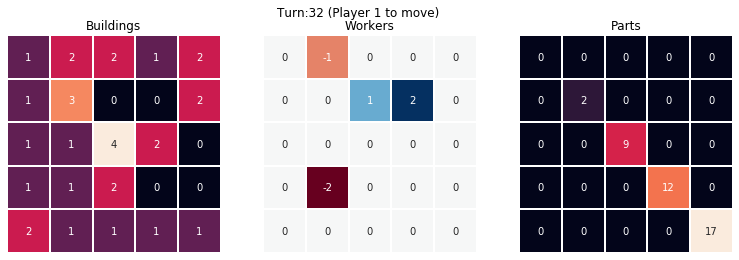

====== Done ======
*Turn:33, Score=0, Done=True, cur_player=-1


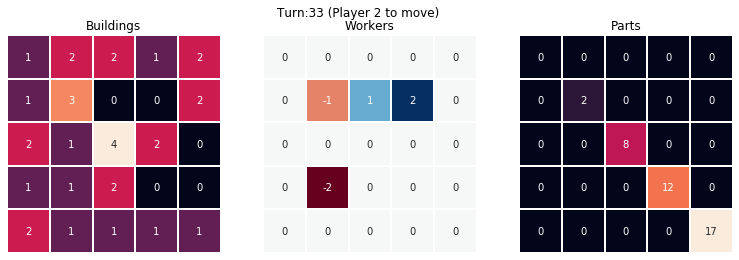

Player 1 Won


In [9]:
#automatically switches player in env.step()
env = Santorini()
n_eps = 1
current_player=-1
#set current_player to be -1
env.current_player=current_player
done = False
while True:
#     print('Turn:{}, Score={}, Done={}, cur_player={}'.format(env.turns,env.score(),done,current_player))
    #visualize board
    env.print_board(mode=1)

    if current_player == -1:
        s, a, r, done, next_player = player1.step(env)
    else:
        s, a, r, done, next_player = player2.step(env)
    
    
    #check if board is done
    if done:
        print('====== Done ======')
        print('*Turn:{}, Score={}, Done={}, cur_player={}'.format(env.turns,env.score(),done,current_player))
        #visualize board
        env.print_board(mode=1)
        
        if r == 1:
            if current_player == -1: #already switched player so we consider previous player as winner
                print('Player 1 Won')
            else:
                print('Player 2 Won')
        elif r == -1:
            if current_player == -1:
                print('Player 2 Won (Player 1 could not make a move)')
            else:
                print('Player 1 Won (Player 2 could not make a move)')
        else:
            print('Draw')
        break
        
    #switch player
    current_player *= -1

# Random Baseline

In [127]:
from collections import deque
from tqdm.notebook import tqdm
#initiate env
env = Santorini()
#initiate policy
policy = RandomPolicy()
#initiate players
player1 = OneStepAgent(policy, -1)
player2 = OneStepAgent(policy, 1)

rewards = []
cnt_w = 0
cnt_l = 0
cnt_d = 0
r_moving_avg = deque(maxlen=1000)
current_player=-1
n_eps = 0
n_max_eps = 0
#set current_player to be -1
env.current_player=current_player
done = False
for i in tqdm(range(10000)):
#     print('Turn:{}, Score={}, Done={}, cur_player={}'.format(env.turns,env.score(),done,current_player))
    #visualize board
#     env.print_board(mode=1)
    if current_player == -1:
        s, a, r, done, next_player = player1.step(env)
    else:
        s, a, r, done, next_player = player2.step(env)
        
#     player1.learn()
    
    #check if board is done
    if done:
        env.reset()
#         print('====== Done ======')
#         print('*Turn:{}, Score={}, Done={}, cur_player={}'.format(env.turns,env.score(),done,current_player))
        #visualize board
#         env.print_board(mode=1)
        if r == 1:
            if current_player == -1: #already switched player so we consider previous player as winner
#                 print('Player 1 Won')
                rewards.append(1)
                cnt_w += 1
            else:
#                 print('Player 2 Won')
                rewards.append(-1)
                cnt_l += 1
        elif r == -1:
            if current_player == -1:
#                 print('Player 2 Won (Player 1 could not make a move)')
                rewards.append(-1)
                cnt_l += 1
            else:
#                 print('Player 1 Won (Player 2 could not make a move)')
                rewards.append(1)
                cnt_w += 1
        else:
#             print('Draw')
            rewards.append(0)
            cnt_d += 1
        if n_eps % 10 == 0:
            try:
                print('Episode {} (i={}): W/L ratio={}, Win={}, Lost={}, Draw={}'.format(n_eps,i, cnt_w/cnt_l, cnt_w, cnt_l, cnt_d))
            except:
                pass
        current_player = -1
        n_eps += 1
        continue
    #switch player
    current_player *= -1

Episode 0 (i=38): W/L ratio=0.0, Win=0, Lost=1, Draw=0
Episode 10 (i=497): W/L ratio=0.8333333333333334, Win=5, Lost=6, Draw=0
Episode 20 (i=946): W/L ratio=1.3333333333333333, Win=12, Lost=9, Draw=0
Episode 30 (i=1382): W/L ratio=1.2142857142857142, Win=17, Lost=14, Draw=0
Episode 40 (i=1868): W/L ratio=1.411764705882353, Win=24, Lost=17, Draw=0
Episode 50 (i=2326): W/L ratio=1.3181818181818181, Win=29, Lost=22, Draw=0
Episode 60 (i=2801): W/L ratio=1.2592592592592593, Win=34, Lost=27, Draw=0
Episode 70 (i=3244): W/L ratio=1.2903225806451613, Win=40, Lost=31, Draw=0
Episode 80 (i=3751): W/L ratio=1.3823529411764706, Win=47, Lost=34, Draw=0
Episode 90 (i=4131): W/L ratio=1.3333333333333333, Win=52, Lost=39, Draw=0
Episode 100 (i=4584): W/L ratio=1.4047619047619047, Win=59, Lost=42, Draw=0
Episode 110 (i=5105): W/L ratio=1.2653061224489797, Win=62, Lost=49, Draw=0
Episode 120 (i=5557): W/L ratio=1.2830188679245282, Win=68, Lost=53, Draw=0
Episode 130 (i=6023): W/L ratio=1.14754098360655

# Training Loop

In [122]:
from collections import deque
from tqdm.notebook import tqdm
#initiate env
env = Santorini()
#initiate policy
policy = RandomPolicy()
#initiate players
player1 = DQNAgent(current_player=-1, batch_size=4)
player2 = OneStepAgent(policy, 1)

rewards = []
cnt_w = 0
cnt_l = 0
cnt_d = 0
r_moving_avg = deque(maxlen=1000)
current_player=-1
n_eps = 0
n_max_eps = 0
#set current_player to be -1
env.current_player=current_player
done = False
for i in tqdm(range(10000)):
#     print('Turn:{}, Score={}, Done={}, cur_player={}'.format(env.turns,env.score(),done,current_player))
    #visualize board
#     env.print_board(mode=1)
    if current_player == -1:
        s, a, r, done, next_player = player1.step(env)
    else:
        s, a, r, done, next_player = player2.step(env)
        
    player1.learn()
    
    #check if board is done
    if done:
        env.reset()
#         print('====== Done ======')
#         print('*Turn:{}, Score={}, Done={}, cur_player={}'.format(env.turns,env.score(),done,current_player))
        #visualize board
#         env.print_board(mode=1)
        if r == 1:
            if current_player == -1: #already switched player so we consider previous player as winner
#                 print('Player 1 Won')
                rewards.append(1)
                cnt_w += 1
            else:
#                 print('Player 2 Won')
                rewards.append(-1)
                cnt_l += 1
        elif r == -1:
            if current_player == -1:
#                 print('Player 2 Won (Player 1 could not make a move)')
                rewards.append(-1)
                cnt_l += 1
            else:
#                 print('Player 1 Won (Player 2 could not make a move)')
                rewards.append(1)
                cnt_w += 1
        else:
#             print('Draw')
            rewards.append(0)
            cnt_d += 1
        if n_eps % 10 == 0:
            try:
                print('Episode {} (i={}): W/L ratio={}, Win={}, Lost={}, Draw={}'.format(n_eps,i, cnt_w/cnt_l, cnt_w, cnt_l, cnt_d))
            except:
                pass
        current_player = -1
        n_eps += 1
        continue
    #switch player
    current_player *= -1

======= configuration =======
current_player: -1
lr:0.0001
gamma:0.99
tau:0.001
mode:dense
bs:4
epsilon:0.3, min_eps:0.01, eps_decay:0.99
tensorboard log_dir at:  logs/20191118-140331/
save model path is:  models/


W1118 14:03:31.695026 4613021120 base_layer.py:1814] Layer dense_network_183 is casting an input tensor from dtype float64 to the layer's dtype of float32, which is new behavior in TensorFlow 2.  The layer has dtype float32 because it's dtype defaults to floatx.

If you intended to run this layer in float32, you can safely ignore this warning. If in doubt, this warning is likely only an issue if you are porting a TensorFlow 1.X model to TensorFlow 2.

To change all layers to have dtype float64 by default, call `tf.keras.backend.set_floatx('float64')`. To change just this layer, pass dtype='float64' to the layer constructor. If you are the author of this layer, you can disable autocasting by passing autocast=False to the base Layer constructor.



Episode 31: W/L ratio=0.0, Win=0, Lost=1, Draw=0
Episode 513: W/L ratio=0.8333333333333334, Win=5, Lost=6, Draw=0
Episode 1014: W/L ratio=0.75, Win=9, Lost=12, Draw=0
Episode 1513: W/L ratio=0.55, Win=11, Lost=20, Draw=0
Episode 1896: W/L ratio=0.782608695652174, Win=18, Lost=23, Draw=0
Episode 2284: W/L ratio=0.8214285714285714, Win=23, Lost=28, Draw=0
Episode 2686: W/L ratio=0.7428571428571429, Win=26, Lost=35, Draw=0
Episode 3133: W/L ratio=0.6904761904761905, Win=29, Lost=42, Draw=0
Episode 3597: W/L ratio=0.8409090909090909, Win=37, Lost=44, Draw=0
Episode 4044: W/L ratio=0.82, Win=41, Lost=50, Draw=0
Episode 4520: W/L ratio=0.7413793103448276, Win=43, Lost=58, Draw=0
Episode 5084: W/L ratio=0.6818181818181818, Win=45, Lost=66, Draw=0
Episode 5592: W/L ratio=0.6575342465753424, Win=48, Lost=73, Draw=0
Episode 6036: W/L ratio=0.7012987012987013, Win=54, Lost=77, Draw=0
Episode 6515: W/L ratio=0.6987951807228916, Win=58, Lost=83, Draw=0
Episode 7040: W/L ratio=0.7159090909090909, Wi

In [ ]:
from collections import deque
from tqdm.notebook import tqdm
#initiate env
env = Santorini()
#initiate policy
policy = RandomPolicy()
#initiate players
player1 = DQNAgent(current_player=-1, batch_size=4)
player2 = DQNAgent(current_player=1, batch_size=4)
turns = []
rewards = []
cnt_w = 0
cnt_l = 0
cnt_d = 0
r_moving_avg = deque(maxlen=1000)
current_player=-1
n_eps = 0
n_max_eps = 0
#set current_player to be -1
env.current_player=current_player
done = False
for i in tqdm(range(10000)):
#     print('Turn:{}, Score={}, Done={}, cur_player={}'.format(env.turns,env.score(),done,current_player))
    #visualize board
#     env.print_board(mode=1)
    if current_player == -1:
        s, a, r, done, next_player = player1.step(env)
    else:
        s, a, r, done, next_player = player2.step(env)
        
    player1.learn()
    player2.learn()
    #check if board is done
    if done:
        turns.append()
        env.reset()
#         print('====== Done ======')
#         print('*Turn:{}, Score={}, Done={}, cur_player={}'.format(env.turns,env.score(),done,current_player))
        #visualize board
#         env.print_board(mode=1)
        if r == 1:
            if current_player == -1: #already switched player so we consider previous player as winner
#                 print('Player 1 Won')
                rewards.append(1)
                cnt_w += 1
            else:
#                 print('Player 2 Won')
                rewards.append(-1)
                cnt_l += 1
        elif r == -1:
            if current_player == -1:
#                 print('Player 2 Won (Player 1 could not make a move)')
                rewards.append(-1)
                cnt_l += 1
            else:
#                 print('Player 1 Won (Player 2 could not make a move)')
                rewards.append(1)
                cnt_w += 1
        else:
#             print('Draw')
            rewards.append(0)
            cnt_d += 1
        if n_eps % 10 == 0:
            try:
                print('Episode {} (i={}): W/L ratio={}, Win={}, Lost={}, Draw={}'.format(n_eps,i, cnt_w/cnt_l, cnt_w, cnt_l, cnt_d))
            except:
                pass
        current_player = -1
        n_eps += 1
        continue
    #switch player
    current_player *= -1

======= configuration =======
current_player: -1
lr:0.0001
gamma:0.99
tau:0.001
mode:dense
bs:4
epsilon:0.3, min_eps:0.01, eps_decay:0.99
tensorboard log_dir at:  logs/20191118-151105/
save model path is:  models/
======= configuration =======
current_player: 1
lr:0.0001
gamma:0.99
tau:0.001
mode:dense
bs:4
epsilon:0.3, min_eps:0.01, eps_decay:0.99
tensorboard log_dir at:  logs/20191118-151105/
save model path is:  models/


W1118 15:11:05.368273 4613021120 base_layer.py:1814] Layer dense_network_187 is casting an input tensor from dtype float64 to the layer's dtype of float32, which is new behavior in TensorFlow 2.  The layer has dtype float32 because it's dtype defaults to floatx.

If you intended to run this layer in float32, you can safely ignore this warning. If in doubt, this warning is likely only an issue if you are porting a TensorFlow 1.X model to TensorFlow 2.

To change all layers to have dtype float64 by default, call `tf.keras.backend.set_floatx('float64')`. To change just this layer, pass dtype='float64' to the layer constructor. If you are the author of this layer, you can disable autocasting by passing autocast=False to the base Layer constructor.

W1118 15:11:05.398757 4613021120 base_layer.py:1814] Layer dense_network_185 is casting an input tensor from dtype float64 to the layer's dtype of float32, which is new behavior in TensorFlow 2.  The layer has dtype float32 because it's dtype de

Episode 10 (i=490): W/L ratio=4.5, Win=9, Lost=2, Draw=0
Episode 20 (i=961): W/L ratio=2.0, Win=14, Lost=7, Draw=0
Episode 30 (i=1435): W/L ratio=1.8181818181818181, Win=20, Lost=11, Draw=0
Episode 40 (i=1904): W/L ratio=1.7333333333333334, Win=26, Lost=15, Draw=0
Episode 50 (i=2358): W/L ratio=1.2173913043478262, Win=28, Lost=23, Draw=0
Episode 60 (i=2798): W/L ratio=1.44, Win=36, Lost=25, Draw=0
Episode 70 (i=3284): W/L ratio=1.3666666666666667, Win=41, Lost=30, Draw=0
Episode 80 (i=3698): W/L ratio=1.3823529411764706, Win=47, Lost=34, Draw=0
Episode 90 (i=4081): W/L ratio=1.3333333333333333, Win=52, Lost=39, Draw=0
Episode 100 (i=4501): W/L ratio=1.3488372093023255, Win=58, Lost=43, Draw=0
Episode 110 (i=4936): W/L ratio=1.2653061224489797, Win=62, Lost=49, Draw=0
Episode 120 (i=5299): W/L ratio=1.1228070175438596, Win=64, Lost=57, Draw=0
Episode 130 (i=5727): W/L ratio=1.0793650793650793, Win=68, Lost=63, Draw=0
Episode 140 (i=6216): W/L ratio=1.0142857142857142, Win=71, Lost=70, D